# RSML (openalea) – Lecture, visualisation et mesures 

## Utilisation

### Imports et variables globales


Le package ```RSML``` de python permet: 

- D'importer/exporter des fichier .rsml
- D'effectuer des visualisation (plot) des architectures racinaires
- D'effectuer des mesures sur les système racinaires ainsi enregistrés

Le package  ```MTG``` (Multiscale Tree Graph) est utilisé pour la manipulation des graphes représentant les architectures racinaires. En simple, c'est un qui contient avec une relation de hierarchie: la plante > ses primaires > ses latérales. Pour déterminer la longeur d'une racine latérale, on sélectionne donc la plante, la primaire  rattachée, puis la latérale et on itére sur sa géométrie pour sommer la longeur des segments. 

In [ ]:
from rsml import rsml2mtg  # Pour importer des fichiers .rsml et les convertir en MTG
from tifffile import TiffFile  # Pour lire les fichiers TIFF (Images)

import matplotlib.pyplot as plt  # Pour les visualisations en général
from rsml import plot2d  # Pour visualiser les systèmes racinaires
import seaborn as sns  # Pour les visualisations avancées
import io # Pour manipuler des flux de données en mémoire
from ipywidgets import IntSlider, Play, jslink, HBox, VBox, Image, IntProgress, HTML # Pour créer des widgets interactifs dans les notebooks

# Pour copier des objets dans la mémoire sans faire de référence
from rsml.misc import plant_vertices, root_vertices # Pour extraire les coordonnées des sommets des plantes et des racines
from copy import deepcopy
from openalea.mtg import MTG  # Pour manipuler les MTG
import numpy as np  # Pour les calculs numériques sur les tableaux
import pandas as pd  # Pour setup des tables de données et les sauvegarder au format csv


PIXEL_SIZE = 1000 * 0.0254 / 600.0  # Taille d'un pixel en milimètres !!!!!!!!

#### Utilitaires (à skip)

In [ ]:
# Utilitaires pour manipuler les graphs 
def extract_mtg_at_time_t(g: MTG, t: float) -> MTG:
    """
    Extrait un sous-graphe de g, projeté à un instant t donné.
    """
    g_new = deepcopy(g)

    time_prop = g_new.property("time")
    time_h_prop = g_new.property("time_hours")
    diameter_prop = g_new.property("diameter")
    geometry_prop = g_new.property("geometry")
    
    if t == -1: 
        t = max(max(time_h_prop.values()))

    def _truncate_lists(prop, idx, v):
        val = prop.get(v)
        if isinstance(val, (list, tuple)) and len(val) > idx + 1:
            prop[v] = val[: idx + 1]  # garde 0…idx
        
    to_remove = []
    for v, serie in time_prop.items():
        first_t = serie[0]
        if first_t > t:
            to_remove.append(v)
        else:
            idx = max(i for i, tau in enumerate(serie) if tau <= t)

            _truncate_lists(time_prop, idx, v)
            _truncate_lists(time_h_prop, idx, v)
            _truncate_lists(diameter_prop, idx, v)
            _truncate_lists(geometry_prop, idx, v)

            # if list is empty has 1 or less elements, remove vertex
            if len(geometry_prop[v]) <= 1:
                to_remove.append(v)

    for v in to_remove:
        try:
            g_new.remove_tree(v)
        except Exception:
            g_new.remove_vertex(v, reparent_child=False)

    return g_new

def ajust_time_with_plante_index(graph: MTG, root_index: int, time: float) -> float:
    # if time is < to appearance time of root_index, return appearance time
    # if time > appearance time, return last time
    graph_of_plant = graph.sub_mtg(root_index)
    time_prop = graph_of_plant.property("time")
    appearance_time = 1e6
    last_time = 0
    for root in graph_of_plant.vertices(scale=1):
        appearance_time = min(time_prop[root][0], appearance_time)
        last_time = max(time_prop[root][-1], last_time)
    if time < appearance_time:
        print("Le temps ajusté est le temps d'apparition de la plante :", appearance_time)
        return appearance_time # on ajoute 1 pour éviter d'avoir une longueur nulle
    if time > last_time:
        print("Le temps ajusté est le dernier temps de la plante :", last_time)
        return last_time 
    return time

def get_corresponding_time_in_hours(graph: MTG, time: float) -> float:
    metadata = graph.graph_properties().get("metadata", {})
    obs_hours_str = metadata.get("observation-hours", None)
    if obs_hours_str is None:
        raise ValueError("Le graphe ne contient pas la clé 'observation-hours' dans ses métadonnées.")
    obs_hours = np.array([float(x) for x in obs_hours_str.split(",") if x.strip() != ""])
    return obs_hours[int(time)]

## Visualisations

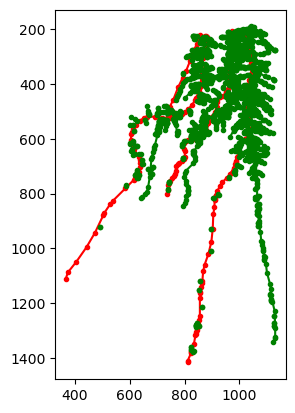

In [ ]:
rsml_path = "/home/loai/Documents/code/RSMLExtraction/temp/jean_trap/61_graph.rsml" # "chemin/vers/fichier.rsml" # chemin vers le fichier rsml à étudier
graph = rsml2mtg(rsml_path)

plot2d(graph)

In [ ]:
img_path = "/home/loai/Documents/code/RSMLExtraction/temp/zinput/22_registered_stack.tif"
img_slices = np.array([])
with TiffFile(img_path) as tif:
    nb_images = len(tif.pages)
    img_slices = np.array([tif.pages[i].asarray() for i in range(nb_images)])
print("Nombre d'images dans le stack :", nb_images)

Nombre d'images dans le stack : 22


In [ ]:
# Repris du package RSML mais légerement modifié pour une meilleure visualisation (transparence, épaisseur de ligne, épaisseur des points)
def plot2d(g, img_file=None, axis=None, root_id=None, color=None, order=None, clear=True, linewidth=.3, **args):
    """ Plot MTG with grains on the initial image.

    :Parameters:
        - g : MTG with properties like 2D coordinates and grains.

    :Optional Parameters:
        - img_file : an array, or the filename, of an image to display in background
        - axis : matplotlib axis to display several plot in the same figure
        - root_id : if None, root_id is the first root of the MTG at scale=max_scale .
          Draw all the descendants of root_id. 
          root_id can also be a list of vertices.
        - order : draw only vertices of order 'order'
        - color: function or dict to define the color of each vertex. 
          Format is matplotlib colors (e.g. 'b', 'g', 'y', 'r')
        - linewidth : float, épaisseur de la ligne (défaut: 1.0)
    """  
    import numpy as np  
    from collections.abc import Iterable
    import matplotlib.pyplot as plt

    if img_file is not None:
        if isinstance(img_file, str):
            image = plt.imread(img_file)
        else:
            image = img_file
        if axis:
            ax_img = axis.imshow(image) 
            axis.autoscale(enable=False)
        else:
            ax_img = plt.imshow(image) 
            plt.gca().autoscale(enable=False)

    ##{0:'r', 1:'g', 2:'b', 3:'y', 4:'c', 5: 'm', 6:'y', 7:'k'}
    colors = 'rgbycmyk'

    root_scale = g.max_scale()
    polylines = g.property('geometry')

    if root_id is None:
        vertices = list(polylines.keys())
    elif isinstance(root_id, Iterable):
        vertices = [v for r in root_id
                    for vr in g.component_roots_at_scale(r, scale=root_scale) 
                    for v in g.Descendants(vr)]
    else:
        vid = g.component_roots_at_scale(root_id, scale=root_scale)
        vertices = g.Descendants(vid)

    check_order = order is not None

    if axis: 
        plot_fct = axis.plot
    else:    
        plot_fct = plt.plot

    for v in vertices:
        _order = g.order(v)
        if check_order and _order != order:
            continue         

        _color = color(v) if color else colors[_order % len(colors)]  # .get(_order,'r')
        poly = np.array(polylines[v])          
        plot_fct(poly[:, 0], poly[:, 1], color=_color, marker='.', markersize=.5, linewidth=linewidth, alpha=0.7)

    if img_file is None:
        if axis:
            ax = axis
        else:
            ax = plt.gca()
            ax.set_ylim(sorted(ax.get_ylim(), reverse=True))
        ax.set_aspect('equal', adjustable='box')

In [ ]:


t_max = int(max(max(graph.property("time").values())))
time_label = "t"
    

t_values = list(range(0, t_max + 1)) 

fig = plt.figure()
ax = plt.gca()
plot2d(extract_mtg_at_time_t(graph, t=-1),  markersize=0.1, img_file=img_slices[0])
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
plt.close(fig)

imgs = []
progress = IntProgress(min=0, max=len(t_values), description="Pré-calcul…")
status = HTML()
display(HBox([progress, status]))

for i, t in enumerate(t_values):
    fig = plt.figure(figsize=(4, 4))
    ax = plt.gca()
    plot2d(extract_mtg_at_time_t(graph, t=t),  markersize=0.1, img_file=img_slices[t])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f"t = {t} {time_label}")

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    imgs.append(buf.getvalue())

    progress.value = i + 1
    status.value = f"{i+1}/{len(t_values)} images"

status.value = f"OK ({len(t_values)} images)"

img_widget = Image(value=imgs[0], format='png')
slider = IntSlider(min=0, max=len(t_values)-1, step=1, value=0, description=f"t ({time_label})")
play = Play(interval=200, value=0, min=0, max=len(t_values)-1, step=1)
jslink((play, 'value'), (slider, 'value'))

def on_change(change):
    idx = change['new']
    img_widget.value = imgs[idx]

slider.observe(on_change, names='value')

VBox([HBox([play, slider]), img_widget])

In [7]:
indices_racines = graph.vertices(scale=1)
print("Indices des primaires, de gauche à droite sur l'image :", indices_racines) # Nombre de somilimètreets au niveau 1

Indices des primaires, de gauche à droite sur l'image : [1, 22, 108, 252]


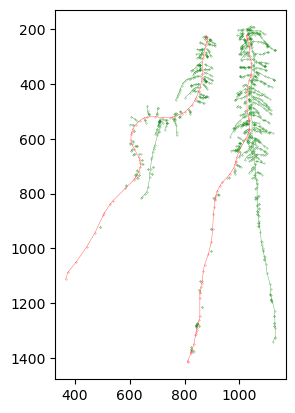

In [ ]:
plot2d(graph, root_id=[indices_racines[1], indices_racines[-1]]) # On donne en paramètre les indices des racines des racines des plantes à afficher (en l'occurrence la 2ème numéro 22 et la dernière numéro 252)

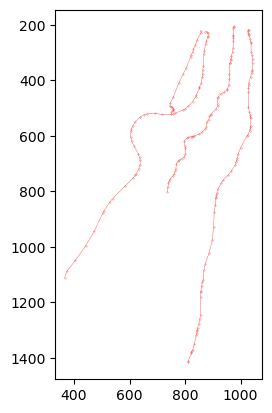

In [9]:
order = 1
plot2d(graph, order=order-1)  # Visualisation du graph d'ordre 1 (primaires)

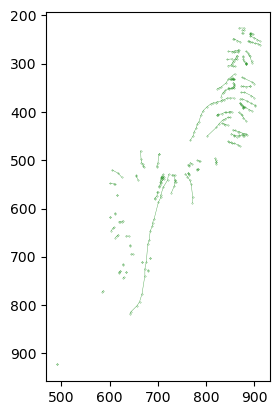

In [10]:
order = 2
plot2d(graph, root_id=[indices_racines[1]], order=order-1)  # Visualisation du graph d'ordre 2 (latérales) pour la seconde plante (indice 20)

## Mesures

### Décompte

In [ ]:
def compte_nombre_plantes(graph):
    """ 
    Compte le nombre de plantes dans le graph.
    """
    
    return len(plant_vertices(graph))

print("Nombre de primaires dans l'image:", compte_nombre_plantes(graph))

Nombre de primaires dans l'image: 4


In [12]:
def compte_nombres_racines(graph, root_index = None, time = None):
    """ 
    Compte le nombre de racines dans le graph.
    Si root_index est fourni, compte le nombre de racines pour la plante d'indice root_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
        
    if root_index is not None:
        from rsml.misc import root_vertices
        from openalea.mtg import MTG
        subgmtg = MTG.sub_mtg(mtg, root_index)
        return len(root_vertices(subgmtg))
    from rsml.misc import root_vertices
    
    root_count = 0
    for root in root_vertices(mtg):
        if root not in mtg.property("geometry"):
            continue
        root_count += 1 
    return root_count

print("Nombre de racines dans l'image:", compte_nombres_racines(graph))
print(f"Nombre de racines de la plante d'indice {indices_racines[1]}:", compte_nombres_racines(graph, root_index=indices_racines[1]))
print(f"Nombre de racines de la plante d'indice {indices_racines[1]} jusqu'à la 10eme capture après la première acquisition:", compte_nombres_racines(graph, root_index=indices_racines[1], time=10))

Nombre de racines dans l'image: 434
Nombre de racines de la plante d'indice 22: 85
Nombre de racines de la plante d'indice 22 jusqu'à la 10eme capture après la première acquisition: 5


In [13]:
def compte_nombres_racines_laterales(graph, root_index = None, time = None):
    """
    Compte le nombre de racines latérales dans le graph.
    Si root_index est fourni, compte le nombre de racines latérales pour la plante d'indice root_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    if root_index is not None:
        from rsml.misc import root_vertices
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(mtg, root_index)
        rv = root_vertices(subgraph)
        lateral_vertices = [v for v in rv if subgraph.parent(v) is not None]
        return len(lateral_vertices) if lateral_vertices else 0.0
    
    from rsml.misc import root_vertices
    rv = root_vertices(mtg)
    lateral_vertices = [v for v in rv if mtg.parent(v) is not None]
    return len(lateral_vertices) if lateral_vertices else 0.0

print("Nombre de racines latérales dans l'image:", compte_nombres_racines_laterales(graph))
print(f"Nombre de racines latérales associée à la primaire d'indice {indices_racines[3]}:", compte_nombres_racines_laterales(graph, root_index=indices_racines[3]))
print(f"Nombre de racines latérales associée à la primaire d'indice {indices_racines[3]}:", compte_nombres_racines_laterales(graph, root_index=indices_racines[1], time=0))

Nombre de racines latérales dans l'image: 430
Nombre de racines latérales associée à la primaire d'indice 252: 185
Nombre de racines latérales associée à la primaire d'indice 252: 0.0


### Longueur racinaires

In [14]:
def longueur_racines(graph, root_index = None, time = None):
    """"
    Calcule la longueur totale des racines dans le graph (en mètres).
    Si root_index est fourni, calcule la longueur totale des racines pour la plante d'indice root_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    from rsml.misc import root_vertices
    if root_index is not None:
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(graph, root_index)
        roots = root_vertices(subgraph)
        total_length = 0.0
        for root in roots:
            geometry = subgraph.property("geometry")
            if root not in geometry:
                continue
            polyline = geometry[root]
            for i in range(len(polyline) - 1):
                length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                          (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
                total_length += length
        return total_length * PIXEL_SIZE
    
    roots = mtg.vertices(scale=mtg.max_scale())
    total_length = 0.0
    for root in roots:
        geometry = mtg.property("geometry")
        if root not in geometry:
            continue                
        polyline = geometry[root]
        for i in range(len(polyline) - 1):
            length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                      (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
            total_length += length
    return total_length * PIXEL_SIZE

print("Longueur totale des racines dans l'image (en milimètre):", longueur_racines(graph, root_index=None))
print(f"Longueur totale des racines de la racine d'indice {indices_racines[0]} (en milimètre):", longueur_racines(graph, root_index=indices_racines[0]))
print(f"Longueur totale des racines de la racine d'indice {indices_racines[0]} jusqu'à la 10eme capture après la première acquisition (en milimètre):", longueur_racines(graph, root_index=indices_racines[0], time=10))

Longueur totale des racines dans l'image (en milimètre): 472.67385378516775
Longueur totale des racines de la racine d'indice 1 (en milimètre): 18.235963558823492
Longueur totale des racines de la racine d'indice 1 jusqu'à la 10eme capture après la première acquisition (en milimètre): 18.235963558823492


In [15]:
def longueur_primaire(graph, root_index, time = None):
    """"
    Calcule la longueur des racines primaires dans le graph (en mètres).
    Si root_index est fourni, calcule la longueur totale des racines pour la plante d'indice root_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    from rsml.misc import root_vertices
    if root_index is not None:
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(mtg, root_index)
        roots = root_vertices(subgraph)
        total_length = 0.0
        for root in roots:
            if subgraph.order(root) != 0:
                continue
            geometry = subgraph.property("geometry")
            if root not in geometry:
                continue
            polyline = geometry[root]
            for i in range(len(polyline) - 1):
                length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                          (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
                total_length += length
        return total_length * PIXEL_SIZE
    
    roots = root_vertices(mtg)
    total_length = 0.0
    for root in roots:
        if mtg.order(root) != 0:
            continue
        geometry = mtg.property("geometry")
        if root not in geometry:
            continue   
        polyline = geometry[root]
        for i in range(len(polyline) - 1):
            length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                      (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
            total_length += length
    return total_length * PIXEL_SIZE

print("Longueur totale des racines primaires dans l'image (en milimètre):", longueur_primaire(graph, root_index=None))
print(f"Longueur totale des racines primaires d'indice {indices_racines[1]} (en milimètre):", longueur_primaire(graph, root_index=indices_racines[1]))
print(f"Longueur totale des racines primaires d'indice {indices_racines[1]} jusqu'à la 10eme capture après la première acquisition (en milimètre):", longueur_primaire(graph, root_index=indices_racines[0], time=22))

Longueur totale des racines primaires dans l'image (en milimètre): 145.97575520057043
Longueur totale des racines primaires d'indice 22 (en milimètre): 49.19256219478363
Longueur totale des racines primaires d'indice 22 jusqu'à la 10eme capture après la première acquisition (en milimètre): 13.92354802492769


In [16]:
def longueur_laterales(graph, root_index, time = None):
    """"
    Calcule la longueur des racines latérales dans le graph (en mètres).
    Si root_index est fourni, calcule la longueur totale des racines pour la plante d'indice root_index.
    """
    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    from rsml.misc import root_vertices
    if root_index is not None:
        from openalea.mtg import MTG
        subgraph = MTG.sub_mtg(mtg, root_index)
        roots = root_vertices(subgraph)
        total_length = 0.0
        for root in roots:
            if subgraph.order(root) != 1:
                continue
            geometry = subgraph.property("geometry")
            if root not in geometry:
                continue
            polyline = geometry[root]
            for i in range(len(polyline) - 1):
                length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                          (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
                total_length += length
        return total_length * PIXEL_SIZE
    
    roots = root_vertices(mtg)
    total_length = 0.0
    for root in roots:
        if mtg.order(root) != 1:
            continue
        geometry = mtg.property("geometry")
        if root not in geometry:
            continue   
        polyline = geometry[root]
        for i in range(len(polyline) - 1):
            length = ((polyline[i][0] - polyline[i + 1][0]) ** 2 +
                      (polyline[i][1] - polyline[i + 1][1]) ** 2) ** 0.5
            total_length += length
    return total_length * PIXEL_SIZE

print("Longueur totale des racines latérales dans l'image (en milimètre):", longueur_laterales(graph, root_index=None))
print(f"Longueur totale des racines latérales de la racine d'indice {indices_racines[0]} (en milimètre):", longueur_laterales(graph, root_index=indices_racines[0]))
print(f"Longueur totale des racines latérales de la racine d'indice {indices_racines[0]} jusqu'à la 10eme capture après la première acquisition (en milimètre):", longueur_laterales(graph, root_index=indices_racines[0], time=20))

Longueur totale des racines latérales dans l'image (en milimètre): 326.6980985845965
Longueur totale des racines latérales de la racine d'indice 1 (en milimètre): 4.3124155338958
Longueur totale des racines latérales de la racine d'indice 1 jusqu'à la 10eme capture après la première acquisition (en milimètre): 3.357668568498119


### Enveloppe convexe

In [17]:
def convex_hull(graph, root_index = None, time = None):
    """
    Calcule l'aire du convex hull englobant toutes les racines dans le graph (en m²).
    Si root_index est fourni, calcule l'aire du convex hull pour la plante d'indice root_index.
    """
    import numpy as np
    from scipy.spatial import ConvexHull

    mtg = deepcopy(graph)
    if time is not None:
        mtg = extract_mtg_at_time_t(mtg, time)
    from rsml.misc import root_vertices
    from openalea.mtg import MTG
    
    if root_index is not None:
        subgraph = MTG.sub_mtg(mtg, root_index)
        roots = root_vertices(subgraph)
        points = []
        for root in roots:
            geometry = subgraph.property("geometry")
            if root not in geometry:
                continue
            polyline = geometry[root]
            points.extend(polyline)
            
        if len(points) < 3:
            return 0.0  # Pas assez de points pour former un polygone

        points = np.array(points) * PIXEL_SIZE  # Mètres
        hull = ConvexHull(points)
        return hull.area
    
    roots = root_vertices(mtg)
    points = []
    for root in roots:
        geometry = mtg.property("geometry")
        if root not in geometry:
            continue   
        polyline = geometry[root]
        points.extend(polyline)
    if len(points) < 3:
        return 0.0  # Pas assez de points pour former un polygone
    points = np.array(points) * PIXEL_SIZE  # Mètres
    hull = ConvexHull(points)
    return hull.area
    

print("Aire du convex hull englobant l'ensemble des racines de la plante dans l'image (en mm²):", convex_hull(graph, root_index=None))
print(f"Aire du convex hull englobant la racines d'indice {indices_racines[1]} et ses filles (en mm²):", convex_hull(graph, root_index=indices_racines[1]))
print(f"Aire du convex hull englobant la racines d'indice {indices_racines[1]} et ses filles jusqu'à la 22eme capture après la première acquisition (en mm²):", convex_hull(graph, root_index=indices_racines[0], time=22))

Aire du convex hull englobant l'ensemble des racines de la plante dans l'image (en mm²): 138.82997164158058
Aire du convex hull englobant la racines d'indice 22 et ses filles (en mm²): 90.15407147515359
Aire du convex hull englobant la racines d'indice 22 et ses filles jusqu'à la 22eme capture après la première acquisition (en mm²): 29.36164939746545


### Vitesse de croissance

In [18]:
def vitesse_croissance_primaire(graph, root_index, time1, time2):
    """
    Calcule la vitesse de croissance des racines primaires entre deux temps donnés (en m/h).
    root_index : indice de la plante à analyser
    time1 : temps initial (en heures)
    time2 : temps final (en heures)
    """

    time1_adjusted = ajust_time_with_plante_index(graph, root_index, time1)
    time2_adjusted = ajust_time_with_plante_index(graph, root_index, time2)

    longueur_t1 = longueur_primaire(graph, root_index=root_index, time=time1_adjusted)
    longueur_t2 = longueur_primaire(graph, root_index=root_index, time=time2_adjusted)
    #print(time1, time1_adjusted, time2, time2_adjusted)
    if time2_adjusted < time1_adjusted:
        raise ValueError("time2 doit être supérieur à time1")
    elif time1_adjusted == time2_adjusted:
        return 0.0

    vitesse = (longueur_t2 - longueur_t1) / (get_corresponding_time_in_hours(graph, time2_adjusted) - get_corresponding_time_in_hours(graph, time1_adjusted))
    return vitesse

print(f"Vitesse de croissance des racines primaires de la plante d'indice {indices_racines[1]} entre la 0 et la 21e capture (en m/h):", vitesse_croissance_primaire(graph, root_index=indices_racines[1], time1=0, time2=21))

Le temps ajusté est le temps d'apparition de la plante : 4.0
Vitesse de croissance des racines primaires de la plante d'indice 22 entre la 0 et la 21e capture (en m/h): 0.22774334349436867


In [19]:
def vitesse_croissance_laterales(graph, root_index, time1, time2):
    """
    Calcule la vitesse de croissance des racines latérales entre deux temps donnés (en m/h).
    root_index : indice de la plante à analyser
    time1 : temps initial (en heures)
    time2 : temps final (en heures)
    """

    time1_adjusted = ajust_time_with_plante_index(graph, root_index, time1)
    time2_adjusted = ajust_time_with_plante_index(graph, root_index, time2)

    longueur_t1 = longueur_laterales(graph, root_index=root_index, time=time1_adjusted)
    longueur_t2 = longueur_laterales(graph, root_index=root_index, time=time2_adjusted)

    if time2_adjusted < time1_adjusted:
        raise ValueError("time2 doit être supérieur à time1")
    elif time1_adjusted == time2_adjusted:
        return 0.0

    vitesse = (longueur_t2 - longueur_t1) / ( get_corresponding_time_in_hours(graph, time2_adjusted) - get_corresponding_time_in_hours(graph, time1_adjusted))
    return vitesse

print(f"Vitesse de croissance des racines latérales de la plante d'indice {indices_racines[1]} entre la 0 et la 21e capture (en m/h):", vitesse_croissance_laterales(graph, root_index=indices_racines[1], time1=0, time2=21))

Le temps ajusté est le temps d'apparition de la plante : 4.0
Vitesse de croissance des racines latérales de la plante d'indice 22 entre la 0 et la 21e capture (en m/h): 0.29541659973417106


In [20]:
def acceleration_croissance_primaire(graph, root_index, time1, time2, time3):
    """
    Calcule l'accélération de croissance des racines primaires entre trois temps donnés (en m/h²).
    root_index : indice de la plante à analyser
    time1 : premier temps (en heures)
    time2 : deuxième temps (en heures)
    time3 : troisième temps (en heures)
    """

    time1_adjusted = ajust_time_with_plante_index(graph, root_index, time1)
    time2_adjusted = ajust_time_with_plante_index(graph, root_index, time2)
    time3_adjusted = ajust_time_with_plante_index(graph, root_index, time3)

    vitesse1 = vitesse_croissance_primaire(graph, root_index, time1_adjusted, time2_adjusted)
    vitesse2 = vitesse_croissance_primaire(graph, root_index, time2_adjusted, time3_adjusted)

    if time3_adjusted < time2_adjusted or time2_adjusted < time1_adjusted:
        raise ValueError("time3 doit être supérieur à time2 et time2 doit être supérieur à time1")
    elif time3_adjusted == time2_adjusted or time2_adjusted == time1_adjusted:
        return 0.0

    acceleration = (vitesse2 - vitesse1) / (get_corresponding_time_in_hours(graph, time3_adjusted) - get_corresponding_time_in_hours(graph, time1_adjusted))  # en m/h²
    return acceleration

def acceleration_croissance_laterales(graph, root_index, time1, time2, time3):
    """
    Calcule l'accélération de croissance des racines latérales entre trois temps donnés (en m/h²).
    root_index : indice de la plante à analyser
    time1 : premier temps (en heures)
    time2 : deuxième temps (en heures)
    time3 : troisième temps (en heures)
    """
    
    time1_adjusted = ajust_time_with_plante_index(graph, root_index, time1)
    time2_adjusted = ajust_time_with_plante_index(graph, root_index, time2)
    time3_adjusted = ajust_time_with_plante_index(graph, root_index, time3)

    vitesse1 = vitesse_croissance_laterales(graph, root_index, time1_adjusted, time2_adjusted)
    vitesse2 = vitesse_croissance_laterales(graph, root_index, time2_adjusted, time3_adjusted)

    if time3_adjusted < time2_adjusted or time2_adjusted < time1_adjusted:
        raise ValueError("time3 doit être supérieur à time2 et time2 doit être supérieur à time1")
    elif time3_adjusted == time2_adjusted or time2_adjusted == time1_adjusted:
        return 0.0

    acceleration = (vitesse2 - vitesse1) / (get_corresponding_time_in_hours(graph, time3_adjusted) - get_corresponding_time_in_hours(graph, time1_adjusted))  # en m/h²
    return acceleration

print(f"Accélération de croissance des racines primaires de la plante d'indice {indices_racines[1]} entre la 0 et la 20e capture (en m/h²):", acceleration_croissance_primaire(graph, root_index=indices_racines[1], time1=0, time2=10, time3=20))
print(f"Accélération de croissance des racines latérales de la plante d'indice {indices_racines[1]} entre la 0 et la 20e capture (en m/h²):", acceleration_croissance_laterales(graph, root_index=indices_racines[1], time1=0, time2=10, time3=20))

Le temps ajusté est le temps d'apparition de la plante : 4.0
Accélération de croissance des racines primaires de la plante d'indice 22 entre la 0 et la 20e capture (en m/h²): 0.0005574431300261637
Le temps ajusté est le temps d'apparition de la plante : 4.0
Accélération de croissance des racines latérales de la plante d'indice 22 entre la 0 et la 20e capture (en m/h²): 0.0020539158584111485


## Plot évolutions

### Utilitaire

In [21]:
obs_hours_str = graph.graph_properties().get("metadata", {}).get("observation-hours", None)
T = np.array([float(x) for x in obs_hours_str.split(",") if x.strip() != ""])
T # en heure

array([  0.,  12.,  24.,  36.,  48.,  60.,  72.,  90., 108., 120., 132.,
       144., 156., 168., 180., 192., 204., 216., 228., 240., 252., 264.])

### Décompte

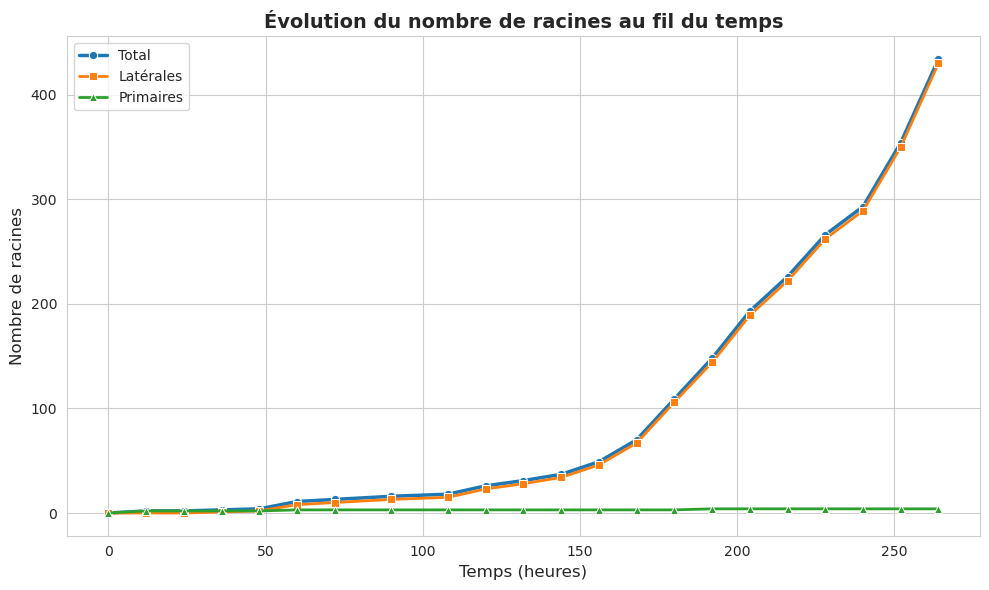

,Temps (h),Racines totales,Racines latérales,Racines primaires
0,0.0,0,0.0,0.0
1,12.0,2,0.0,2.0
2,24.0,2,0.0,2.0
3,36.0,3,1.0,2.0
4,48.0,4,2.0,2.0
5,60.0,11,8.0,3.0
6,72.0,13,10.0,3.0
7,90.0,16,13.0,3.0
8,108.0,18,15.0,3.0
9,120.0,26,23.0,3.0


In [22]:
data = []
for i, t in enumerate(T):
    # Nombre total de racines
    total_roots = compte_nombres_racines(graph, root_index=None, time=i)
    # Nombre de racines latérales
    lateral_roots = compte_nombres_racines_laterales(graph, root_index=None, time=i)
    # Nombre de racines primaires (total - latérales)
    primary_roots = total_roots - lateral_roots
    
    data.append({
        'Temps (h)': t,
        'Racines totales': total_roots,
        'Racines latérales': lateral_roots,
        'Racines primaires': primary_roots
    })

df_roots = pd.DataFrame(data)

# Plot avec seaborn
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Tracer les différentes catégories de racines
sns.lineplot(data=df_roots, x='Temps (h)', y='Racines totales', marker='o', label='Total', linewidth=2.5)
sns.lineplot(data=df_roots, x='Temps (h)', y='Racines latérales', marker='s', label='Latérales', linewidth=2)
sns.lineplot(data=df_roots, x='Temps (h)', y='Racines primaires', marker='^', label='Primaires', linewidth=2)

plt.xlabel('Temps (heures)', fontsize=12)
plt.ylabel('Nombre de racines', fontsize=12)
plt.title('Évolution du nombre de racines au fil du temps', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Afficher aussi le DataFrame
df_roots

### Longueurs

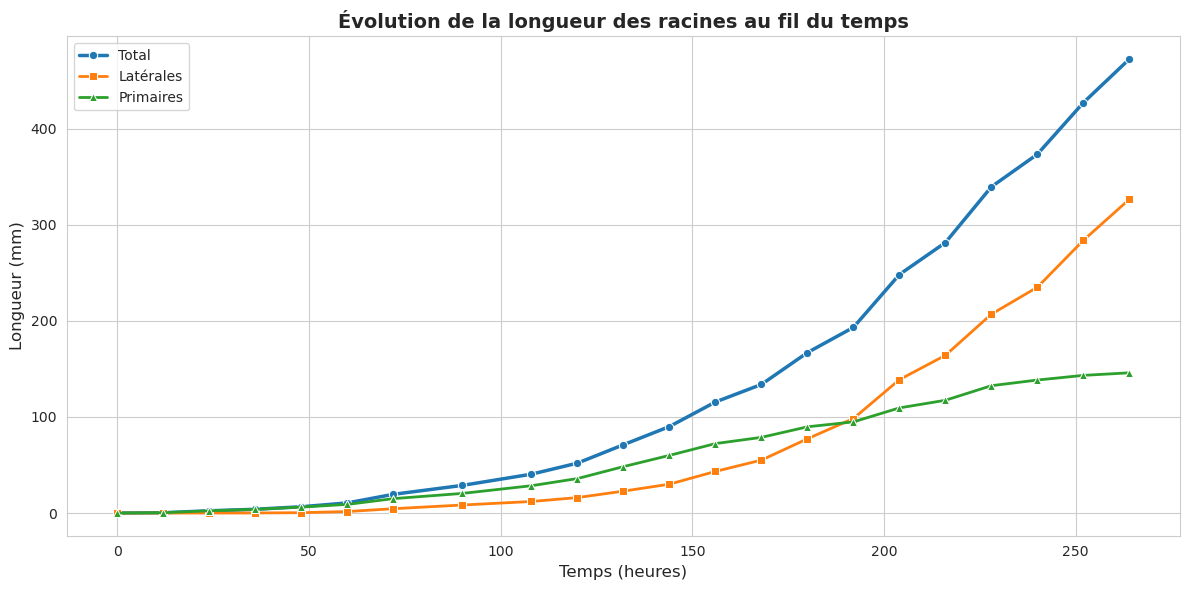


DataFrame des longueurs :


,Temps (h),Longueur totale (mm),Longueur latérales (mm),Longueur primaires (mm)
0,0.0,0.000000,0.000000,0.000000
1,12.0,0.319992,0.000000,0.319992
2,24.0,2.323590,0.000000,2.323590
3,36.0,3.912897,0.059868,3.853028
4,48.0,6.539716,0.351034,6.188683
5,60.0,10.534900,1.540951,8.993949
6,72.0,19.501697,4.504910,14.996786
7,90.0,28.776435,8.347514,20.428921
8,108.0,40.444060,12.008765,28.435294
9,120.0,51.950268,16.069369,35.880899


In [23]:
data_overall = []
for i, t in enumerate(T):
    # Longueur totale
    total_length = longueur_racines(graph, root_index=None, time=i)
    # Longueur des racines latérales
    lateral_length = longueur_laterales(graph, root_index=None, time=i)
    # Longueur des racines primaires
    primary_length = longueur_primaire(graph, root_index=None, time=i)
    
    data_overall.append({
        'Temps (h)': t,
        'Longueur totale (mm)': total_length,
        'Longueur latérales (mm)': lateral_length,
        'Longueur primaires (mm)': primary_length
    })

df_length_overall = pd.DataFrame(data_overall)

# Plot pour l'ensemble
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_length_overall, x='Temps (h)', y='Longueur totale (mm)', 
             marker='o', label='Total', linewidth=2.5)
sns.lineplot(data=df_length_overall, x='Temps (h)', y='Longueur latérales (mm)', 
             marker='s', label='Latérales', linewidth=2)
sns.lineplot(data=df_length_overall, x='Temps (h)', y='Longueur primaires (mm)', 
             marker='^', label='Primaires', linewidth=2)

plt.xlabel('Temps (heures)', fontsize=12)
plt.ylabel('Longueur (mm)', fontsize=12)
plt.title('Évolution de la longueur des racines au fil du temps', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nDataFrame des longueurs :")
display(df_length_overall)

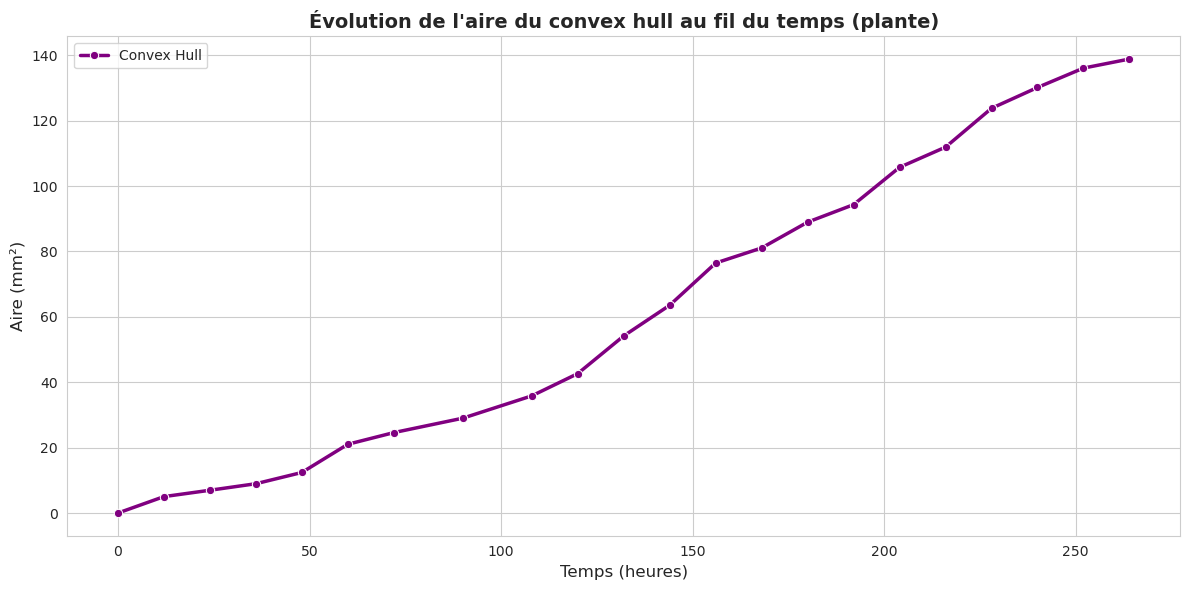

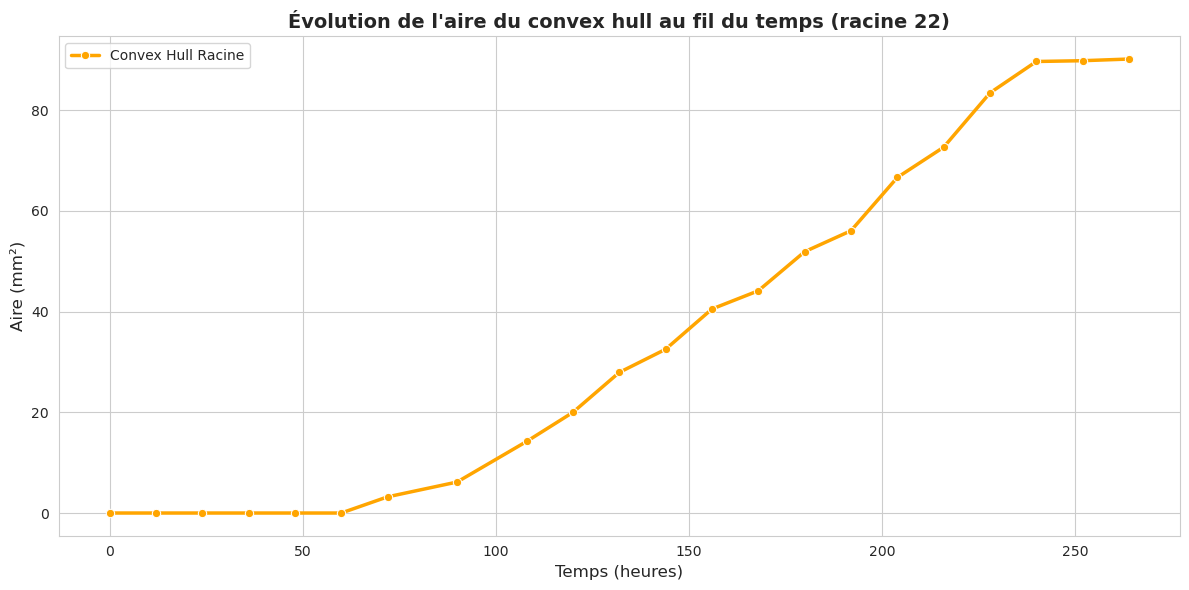


DataFrame du convex hull (plante) :


,Temps (h),Aire convex hull (mm²)
0,0.0,0.000000
1,12.0,5.020124
2,24.0,6.964629
3,36.0,8.961447
4,48.0,12.401389
5,60.0,21.028167
6,72.0,24.594265
7,90.0,28.999800
8,108.0,35.823801
9,120.0,42.631751



DataFrame du convex hull (racine 22) :


,Temps (h),Aire convex hull racine (mm²)
0,0.0,0.000000
1,12.0,0.000000
2,24.0,0.000000
3,36.0,0.000000
4,48.0,0.000000
5,60.0,0.000000
6,72.0,3.211037
7,90.0,6.153310
8,108.0,14.205459
9,120.0,19.992505


In [24]:
root_idx = indices_racines[1]
data_plant_convex = []
data_root_convex = []
for i, t in enumerate(T):
    hull_area = convex_hull(graph, root_index=None, time=i)
    hull_area_root = convex_hull(graph, root_index=root_idx, time=i)

    data_plant_convex.append({
        'Temps (h)': t,
        'Aire convex hull (mm²)': hull_area,
    })
    data_root_convex.append({
        'Temps (h)': t,
        'Aire convex hull racine (mm²)': hull_area_root,
    })

df_plant_convex = pd.DataFrame(data_plant_convex)
df_root_convex = pd.DataFrame(data_root_convex)

# Plot pour le convex hull
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_plant_convex, x='Temps (h)', y='Aire convex hull (mm²)', 
             marker='o', label='Convex Hull', linewidth=2.5, color='purple')

plt.xlabel('Temps (heures)', fontsize=12)
plt.ylabel('Aire (mm²)', fontsize=12)
plt.title('Évolution de l\'aire du convex hull au fil du temps (plante)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(data=df_root_convex, x='Temps (h)', y='Aire convex hull racine (mm²)', 
             marker='o', label='Convex Hull Racine', linewidth=2.5, color='orange')
plt.xlabel('Temps (heures)', fontsize=12)
plt.ylabel('Aire (mm²)', fontsize=12)
plt.title(f'Évolution de l\'aire du convex hull au fil du temps (racine {root_idx})', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nDataFrame du convex hull (plante) :")
display(df_plant_convex)

print(f"\nDataFrame du convex hull (racine {root_idx}) :")
display(df_root_convex)

Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0


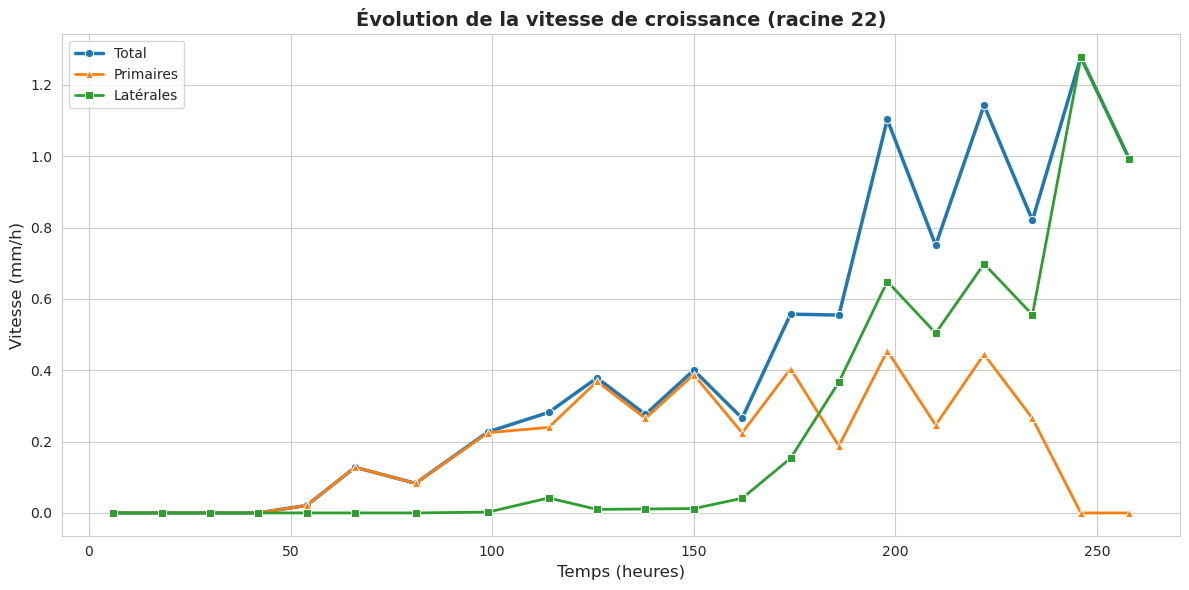


DataFrame des vitesses (racine 22) :


,Temps (h),Vitesse primaires (mm/h),Vitesse latérales (mm/h),Vitesse totale (mm/h)
0,6.0,0.000000,0.000000,0.000000
1,18.0,0.000000,0.000000,0.000000
2,30.0,0.000000,0.000000,0.000000
3,42.0,0.000000,0.000000,0.000000
4,54.0,0.021167,0.000000,0.021167
5,66.0,0.127895,0.000000,0.127895
6,81.0,0.083056,0.000000,0.083056
7,99.0,0.225086,0.002352,0.227438
8,114.0,0.239810,0.041994,0.281804
9,126.0,0.368642,0.009898,0.378541


In [25]:
# 3. Évolution des vitesses de croissance pour une plante spécifique
# Choisir une plante (par exemple la première)
root_idx = indices_racines[1]

data_vitesse = []
for i in range(len(T) - 1):
    t1 = T[i]
    t2 = T[i + 1]

    vitesse_prim = vitesse_croissance_primaire(graph, root_index=root_idx, time1=i, time2=i+1)
    vitesse_lat = vitesse_croissance_laterales(graph, root_index=root_idx, time1=i, time2=i+1)
    
    data_vitesse.append({
        'Temps (h)': (t1 + t2) / 2,  # point milieu
        'Vitesse primaires (mm/h)': vitesse_prim,
        'Vitesse latérales (mm/h)': vitesse_lat,
        'Vitesse totale (mm/h)': vitesse_prim + vitesse_lat
    })

df_vitesse = pd.DataFrame(data_vitesse)

# Plot pour les vitesses
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_vitesse, x='Temps (h)', y='Vitesse totale (mm/h)', 
             marker='o', label='Total', linewidth=2.5)
sns.lineplot(data=df_vitesse, x='Temps (h)', y='Vitesse primaires (mm/h)', 
             marker='^', label='Primaires', linewidth=2)
sns.lineplot(data=df_vitesse, x='Temps (h)', y='Vitesse latérales (mm/h)', 
             marker='s', label='Latérales', linewidth=2)

plt.xlabel('Temps (heures)', fontsize=12)
plt.ylabel('Vitesse (mm/h)', fontsize=12)
plt.title(f'Évolution de la vitesse de croissance (racine {root_idx})', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nDataFrame des vitesses (racine {root_idx}) :")
display(df_vitesse)

Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le temps d'apparition de la plante : 4.0
Le temps ajusté est le t

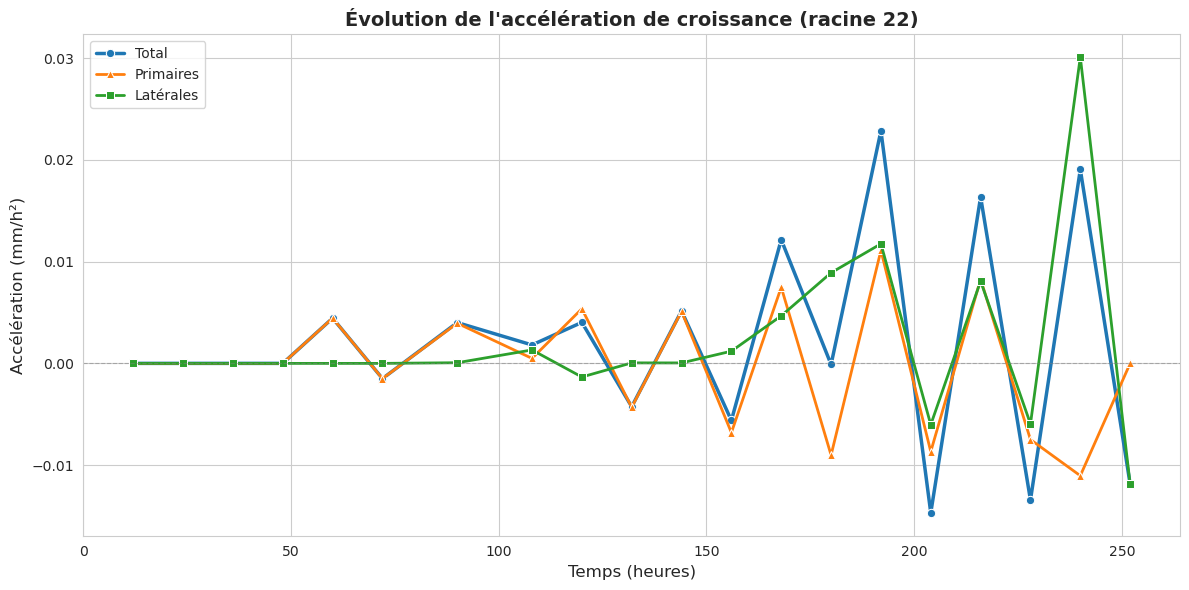


DataFrame des accélérations (racine 22) :


,Temps (h),Accélération primaires (mm/h²),Accélération latérales (mm/h²),Accélération totale (mm/h²)
0,12.0,0.000000,0.000000,0.000000
1,24.0,0.000000,0.000000,0.000000
2,36.0,0.000000,0.000000,0.000000
3,48.0,0.000000,0.000000,0.000000
4,60.0,0.004447,0.000000,0.004447
5,72.0,-0.001495,0.000000,-0.001495
6,90.0,0.003945,0.000065,0.004011
7,108.0,0.000491,0.001321,0.001812
8,120.0,0.005368,-0.001337,0.004031
9,132.0,-0.004312,0.000051,-0.004261


In [26]:
root_idx = indices_racines[1]

data_accel = []
for i in range(len(T) - 2):
    t1 = T[i]
    t2 = T[i + 1]
    t3 = T[i + 2]
    
    accel_prim = acceleration_croissance_primaire(graph, root_index=root_idx, time1=i, time2=i+1, time3=i+2)
    accel_lat = acceleration_croissance_laterales(graph, root_index=root_idx, time1=i, time2=i+1, time3=i+2)
    
    data_accel.append({
        'Temps (h)': t2,  # temps central
        'Accélération primaires (mm/h²)': accel_prim,
        'Accélération latérales (mm/h²)': accel_lat,
        'Accélération totale (mm/h²)': accel_prim + accel_lat
    })

df_accel = pd.DataFrame(data_accel)

# Plot pour les accélérations
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_accel, x='Temps (h)', y='Accélération totale (mm/h²)', 
             marker='o', label='Total', linewidth=2.5)
sns.lineplot(data=df_accel, x='Temps (h)', y='Accélération primaires (mm/h²)', 
             marker='^', label='Primaires', linewidth=2)
sns.lineplot(data=df_accel, x='Temps (h)', y='Accélération latérales (mm/h²)', 
             marker='s', label='Latérales', linewidth=2)

plt.xlabel('Temps (heures)', fontsize=12)
plt.ylabel('Accélération (mm/h²)', fontsize=12)
plt.title(f'Évolution de l\'accélération de croissance (racine {root_idx})', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nDataFrame des accélérations (racine {root_idx}) :")
display(df_accel)

## Exportation

In [27]:
export_dir = "./exported_measurements"
os.makedirs(export_dir, exist_ok=True)

rows_plant = []
rows_root = []

for i_time, t_hours in enumerate(T):
    total_roots = compte_nombres_racines(graph, root_index=None, time=i_time)
    lateral_roots = compte_nombres_racines_laterales(
        graph, root_index=None, time=i_time)
    primary_roots = total_roots - lateral_roots

    total_len_m = longueur_racines(graph, root_index=None, time=i_time)
    lateral_len_m = longueur_laterales(graph, root_index=None, time=i_time)
    primary_len_m = longueur_primaire(graph, root_index=None, time=i_time)

    hull_area_m2 = convex_hull(graph, root_index=None, time=i_time)

    rows_plant.append({
        "scope": "Plant",
        "time_index": i_time,
        "time_hours": t_hours,
        "roots_total": total_roots,
        "roots_lateral": lateral_roots,
        "roots_primary": primary_roots,
        "length_total_mm": total_len_m,
        "length_lateral_mm": lateral_len_m,
        "length_primary_mm": primary_len_m,
        "convex_hull_(raw_units)": hull_area_m2,
        "convex_hull_mm2": hull_area_m2
    })

    for root_idx in indices_racines:
        total_roots_p = compte_nombres_racines(
            graph, root_index=root_idx, time=i_time)
        lateral_roots_p = compte_nombres_racines_laterales(
            graph, root_index=root_idx, time=i_time)
        primary_roots_p = total_roots_p - lateral_roots_p

        total_len_m_p = longueur_racines(
            graph, root_index=root_idx, time=i_time)
        lateral_len_m_p = longueur_laterales(
            graph, root_index=root_idx, time=i_time)
        primary_len_m_p = longueur_primaire(
            graph, root_index=root_idx, time=i_time)

        hull_area_m2_p = convex_hull(graph, root_index=root_idx, time=i_time)

        rows_root.append({
            "scope": "Primary_root",
            "root_index": root_idx,
            "time_index": i_time,
            "time_hours": t_hours,
            "roots_total": total_roots_p,
            "roots_lateral": lateral_roots_p,
            "roots_primary": primary_roots_p,
            "length_total_mm": total_len_m_p,
            "length_lateral_mm": lateral_len_m_p,
            "length_primary_mm": primary_len_m_p,
            "convex_hull_(raw_units)": hull_area_m2_p,
            "convex_hull_mm2": hull_area_m2_p,
        })

df_global = pd.DataFrame(rows_plant)
df_root = pd.DataFrame(rows_root)

df_global.to_csv(os.path.join(
    export_dir, "measure_per_plant.csv"), index=False)
df_root.to_csv(os.path.join(
    export_dir, "measure_per_root.csv"), index=False)


NameError: name 'os' is not defined

In [ ]:
root_rows_speed = []
root_rows_accel = []

# Vitesses
for i_time in range(len(T)-1):
    for root_idx in indices_racines:
        v_prim_mph = vitesse_croissance_primaire(
            graph, root_index=root_idx, time1=i_time, time2=i_time+1)
        v_lat_mph = vitesse_croissance_laterales(
            graph, root_index=root_idx, time1=i_time, time2=i_time+1)
        root_rows_speed.append({
            "plant_index": root_idx,
            "from_time_index": i_time,
            "to_time_index": i_time+1,
            "start_time_hours": T[i_time],
            "end_time_hours": T[i_time+1],
            "speed_primary_mm_per_h": v_prim_mph,
            "speed_lateral_mm_per_h": v_lat_mph,
            "speed_total_mm_per_h": v_prim_mph + v_lat_mph,
        })

# Accélérations
for i_time in range(len(T)-2):
    for root_idx in indices_racines:
        a_prim_mph2 = acceleration_croissance_primaire(
            graph, root_index=root_idx, time1=i_time, time2=i_time+1, time3=i_time+2)
        a_lat_mph2 = acceleration_croissance_laterales(
            graph, root_index=root_idx, time1=i_time, time2=i_time+1, time3=i_time+2)
        root_rows_accel.append({
            "root_index": root_idx,
            "t1_index": i_time,
            "t2_index": i_time+1,
            "t3_index": i_time+2,
            'start_time_hours': T[i_time],
            'mid_time_hours': T[i_time+1],
            'end_time_hours': T[i_time+2],
            "accel_primary_mm_per_h2": a_prim_mph2,
            "accel_lateral_mm_per_h2": a_lat_mph2,
            "accel_total_mm_per_h2": a_prim_mph2 + a_lat_mph2,
        })

df_speed = pd.DataFrame(root_rows_speed)
df_accel = pd.DataFrame(root_rows_accel)

df_speed.to_csv(os.path.join(
    export_dir, "growth_speed_per_root.csv"), index=False)
df_accel.to_csv(os.path.join(
    export_dir, "growth_acceleration_per_root.csv"), index=False)

## Définitions

Un $MTG$ c'est un graph sur lequel on peut itérer pour effectuer des mesures. Il est composé de plusieurs niveaux: 
- Niveau 0: contient l'ensemble du graph et de ses ramifications (i.e. 5 plantes et leurs ramifications)
- Niveau 1: contient le sous-graph correspondant à une unique plante 
- Niveau 2: contient le (sous-)sous-graph correspondant à une racine

-> Si on veut compter l'ensemble des racines de l'image, on travaille au niveau 0

-> Si on veut mesurer l'aire de l'enveloppe convexe d'une plante, on travaille au niveau 1

-> Si on veut mesurer la longeur d'une racine en particulier, on travaille au niveau 2